In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df = pd.read_csv('Admission_Predict.csv')

In [ ]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [ ]:
df= df.drop(columns=['Serial No.'], errors='ignore')

In [ ]:
X = df.drop('Chance of Admit',axis=1)
y = df['Chance of Admit']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Decision Tree

In [ ]:
model = DecisionTreeRegressor(
    max_depth=4,            # control complextiy to avoid overfitting
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)


model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=4, min_samples_leaf=5, min_samples_split=10,
                      random_state=42)

In [ ]:
y_pred = model.predict(X_test)
y_predTrain = model.predict(X_train)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mse2 = mean_squared_error(y_train, y_predTrain)
rmse2 = np.sqrt(mse2)
r2_2= r2_score(y_train, y_predTrain)

print("RMSE:", rmse)
print("R2 Score:", r2)
print("RMSE:", rmse2)
print("R2 Score:", r2_2)


RMSE: 0.07256483429252258
R2 Score: 0.7960894591817118
RMSE: 0.05994619285642743
R2 Score: 0.8098456286278197


##Visual the plot

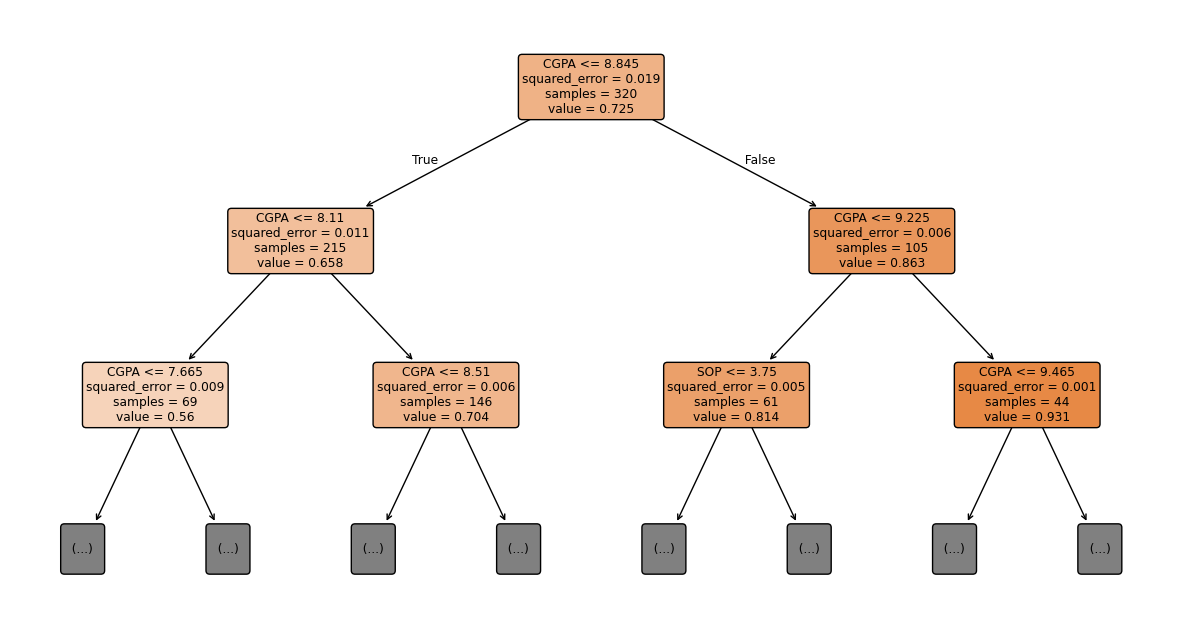

In [ ]:
plt.figure(figsize=(15,8))
plot_tree(
    model,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    max_depth = 2
)
plt.show()

# RandomForest

In [ ]:
modelF = RandomForestRegressor(
    n_estimators=300,
    max_depth=7,
    min_samples_leaf=3,
    random_state=42
)
modelF.fit(X_train, y_train)

RandomForestRegressor(max_depth=7, min_samples_leaf=3, n_estimators=300,
                      random_state=42)

In [ ]:
y_predF = modelF.predict(X_test)

In [ ]:
print("Train R2:", modelF.score(X_train, y_train))
print("Test R2:", modelF.score(X_test, y_test))

mseF = mean_squared_error(y_test, y_predF)
rmseF = np.sqrt(mse)
r2F = r2_score(y_test, y_predF)

print("RMSE:", rmseF)
print("R2 Score:", r2F)

Train R2: 0.89463029736515
Test R2: 0.8159727970902122
RMSE: 0.07256483429252258
R2 Score: 0.8159727970902122
